# **COMP8430 Group project - Phase 3** 

# **Student Name: Sunil Bastola, Minh Hieu Doan, Shaurav Khadka, Sabrin Luitel, Christian Orca, YIU Hok Yu (Jocelyn)**

# **Student ID: 48659851, 48489115, 48541818, 48343188, 48304069, 48715638**

# **Introduction**

Phase 3 extends the pasta classification work from Phase 2, where Phase 2 focused on exploring which pre-trained model settings work best for pasta classification. Phase 3 focuses on deploying the pasta classifier onto a physical robot. Images collected by each team member in Phase 2 are combined, resulting in a total of 21 pasta classes. The model is then fine-tuned using the best settings identified in Phase 2 across all 21 pasta classes. Once trained, images are captured using the robot's camera, which will look different from the original training data due to differences in lighting, angle, and camera quality. Three pasta classes: long, spiral, and tube are selected for image capture from the robot. The best performing model from Phase 2 is then fine-tuned on these robot-captured images to improve performance. Once ready, the classifier is deployed onto the robot, which is programmed to perform actions when it recognises a pasta class.


In [ ]:
import splitfolders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# **Section 1: Capture images from robot**


The following section explains the steps to capture RGB images from the robot’s depth camera using a ROS 2 Python subscriber node. The captured images are saved locally into a selected directory.

## **Section 1.1 Connect to the robot**

First, open NoMachine and connect the robot machine to your computer.
After the connection is successful, open a terminal on the robot machine.


## **Section 1.2 Create the project workspace**
Create a project directory using your student ID or week/project name. Over here, Sunil's student ID is used where the src folder is created under that folder as shown below:

```bash

mkdir -p ~/48659851/comp8430_main_project/src
cd ~/48659851/comp8430_main_project/src
```

### **Section 1.2.1 Create the ROS 2 Python Package**

Inside the src directory, create a ROS 2 Python package named capture_topic.
```bash

ros2 pkg create --build-type ament_python capture_topic --dependencies rclpy sensor_msgs cv_bridge
```
The expected folder structure should look like this:

Now your ```workspcae``` looks like
```bash
48659851/
└── comp8430_main_project/
    └── src/
        └── capture_topic/
            ├── package.xml
            ├── resource/
            │   └── capture_topic
            ├── setup.cfg
            ├── setup.py
            ├── test/
            │   ├── test_copyright.py
            │   ├── test_flake8.py
            │   └── test_pep257.py
            └── capture_topic/
                ├── __init__.py
                └── capture_sub.py


```

### **Section 1.2.2 Create the Image Capture Subscriber**

Go to the Python package folder.
```bash
cd ~/YourMQ_ID/comp8430_main_project/src/capture_topic/capture_topic
```
Create a new Python file.

```bash
touch capture_sub.py
```

Open the file and add the following code.


In [ ]:
import os
import argparse

import rclpy
from rclpy.node import Node
from sensor_msgs.msg import Image
import cv2
from cv_bridge import CvBridge


class CamCapture(Node):
   def __init__(self, name, save_path, num_max):
       super().__init__(name)

       self.cam_subscription = self.create_subscription(
           Image,
           '/depth_cam/rgb/image_raw',
           self.image_callback,
           1
       )

       self.cv_bridge = CvBridge()
       self.save_path = save_path
       os.makedirs(self.save_path, exist_ok=True)

       self.num_max = num_max
       self.save_id = 0

       self.get_logger().info(f"Saving images to: {self.save_path}")
       self.get_logger().info(f"Maximum image count: {self.num_max}")

   def image_callback(self, msg):
       image_bgr = self.cv_bridge.imgmsg_to_cv2(msg, "bgr8")

       cv2.imshow("capture rgb image", image_bgr)

       file_path = os.path.join(self.save_path, f"image{self.save_id}.jpg")
       cv2.imwrite(file_path, image_bgr)

       self.get_logger().info(f"Saved image: {file_path}")

       self.save_id = (self.save_id + 1) % self.num_max

       cv2.waitKey(1)


def main(args=None):
   rclpy.init(args=args)

   parser = argparse.ArgumentParser(description="Save images from ROS 2 topic")

   parser.add_argument(
       "--save_path",
       type=str,
       default="/home/ubuntu/gary/temp_test/comp8430_project-name/captured_images/object"
   )

   parser.add_argument(
       "--num_max",
       type=int,
       default=100
   )

   parsed_args, unknown = parser.parse_known_args()

   node = CamCapture(
       "capture_sub",
       parsed_args.save_path,
       parsed_args.num_max
   )

   try:
       rclpy.spin(node)
   except KeyboardInterrupt:
       pass
   finally:
       node.destroy_node()
       cv2.destroyAllWindows()
       rclpy.shutdown()


if __name__ == "__main__":
   main()


### **Section 1.2.3 Create the Image Capture Subscriber**


Go back to the package root directory.
```bash
cd ~/YourMQ_ID/comp8430_main_project/src/capture_topic
```

Open the setup.py file.

Find the entry_points section and update it as follows, by doing so this register the subscriber.


In [ ]:
entry_points={
   'console_scripts': [
       'capture_subscriber = capture_topic.capture_sub:main',
   ],
},

### **Section 1.2.4 Run and build the workspace**

Go to the workspace root directory.

```bash
cd ~/YourMQ_ID/comp8430_main_project

```

Build the ROS 2 workspace.

```bash
colcon build
```

After the build finishes, source the workspace.

```bash
source install/setup.zsh
```

This allows the node to be executed using the following command:

```bash
ros2 run capture_topic capture_subscriber
```

### **Section 1.3 Launch the Depth Camera**

Launch the depth camera using the following command.

```bash
ros2 launch peripherals depth_camera.launch.py
```

Keep this terminal running.

### **Section 1.3.1 Check the Camera Topic**

Open a new terminal and source the workspace again.

```bash 
cd ~/YourMQ_ID/comp8430_main_project

source install/setup.zsh
```

Check whether the camera topic is available.

```bash
ros2 topic list
```

Look for this topic:

/depth_cam/rgb/image_raw

You can also check topic information.

```bash
ros2 topic info /depth_cam/rgb/image_raw
```

If the topic does not appear, the camera launch file may not be running correctly.

## **Section 1.4 Run the Image Capture Node**

Run the subscriber node.

```bash
ros2 run capture_topic capture_subscriber --save_path ~/captured_images/object --num_max 100
```

This saves captured images into:

~/captured_images/object

The images will be saved as:


image0.jpg



image1.jpg


image2.jpg


...


image99.jpg



After image99.jpg, the program starts overwriting from image0.jpg.

## **Section 1.5 Stop the Program**

To stop the image capture node, press:
Ctrl + C

The image display window will close automatically.

## **Section 1.6 Summary**

Terminal 1 — Launch the Camera

```bash
cd ~/YourMQ_ID/comp8430_main_project
source install/setup.zsh
ros2 launch peripherals depth_camera.launch.py

```

Terminal 2 — Run the Image Capture Node

```bash
cd ~/YourMQ_ID/comp8430_main_project
source install/setup.zsh
ros2 run capture_topic capture_subscriber --save_path ~/captured_images/object --num_max 100

```
**The expected Result**

When the program runs correctly:

The robot camera feed appears in a window named capture rgb image.
The images are saved in the selected folder.
The image file names follow this format:


image0.jpg



image1.jpg



image2.jpg



...
This confirms that the image capture process is working correctly.


# **Section 2: Fine-tune classifer with robot images**

## **Section 2.1: 21 classes finetuning**   

A total of 21 pasta classes are combined together. The 21 pasta classes are split into training, validation and testing dataset with a ratio of 60%, 10% and 30%. ResNet50, the pre-trained model is selected to be inserted where the pre-trained model will be trained using the 21 pasta classes. The same setup as the Phase 2 is dragging into here where stepLR is set for the learning scheduler along with layer 4 and final classifier unfreeze and adding data augmentation to the dataset. The same training losses, validation losses, training accuracies, validation accuracies, learning rate, test accuruacy and confusion matrix are displayed to determine the overall performance of the ResNet50 with 21 pasta classes. 

In [ ]:
# Split the dataset into training, validation and testing dataset with a ratio of 60%, 10% and 30%
splitfolders.ratio("/home/icepomelo/1/images", output="/home/icepomelo/1/images_split", seed=1337, ratio=(0.6, 0.1, 0.3))

Copying files: 2884 files [00:00, 2956.35 files/s]


In [ ]:
# Define transforms for the dataset 
transform = transforms.Compose([

    # Resize image to 224x224 pixels
    transforms.Resize((224, 224)),   

    # Converts the PIL image to a PyTorch tensor values to [0, 1]           
    transforms.ToTensor(),                  
])

# Add the data augmentation transforms 
test_transform = transforms.Compose([
    
    # Add flip to the image 
    transforms.RandomHorizontalFlip(),

    # Add random rotation to the image
    transforms.RandomRotation(15),

    # Add colour jitter to the image
    # So that the contrast and brightness of the image can be changed
    # highlighing the key features and allowing the model to learn accordingly 
    transforms.ColorJitter(brightness=0.3, contrast=0.3),

    # Resize image to 224x224 pixels
    transforms.Resize((224, 224)),   

    # Converts the PIL image to a PyTorch tensor values to [0, 1]           
    transforms.ToTensor(),
    
    # normalise the image with mean and std of Imagenet dataset 
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])                  
])

# Setup and load training dataset for the 21 classes 
train_dataset_finetune_20 = ImageFolder('/home/icepomelo/1/images_split/train', transform = transform)
train_loader_finetune_20 = DataLoader(train_dataset_finetune_20, batch_size = 32, shuffle = True)

# Setup and load validation dataset for the 21 classes
validation_dataset_finetune_20 = ImageFolder('/home/icepomelo/1/images_split/val', transform = transform)
validation_loader_finetune_20 = DataLoader(validation_dataset_finetune_20, batch_size = 32, shuffle = False)

# Setup and load test dataset for the 21 classes
test_dataset_finetune_20 = ImageFolder('/home/icepomelo/1/images_split/test', transform = transform)
test_loader_finetune_20 = DataLoader(test_dataset_finetune_20, batch_size = 32, shuffle = False)

# Setup and load training dataset for the 21 classes with data augmentation
train_dataset_aug = ImageFolder('/home/icepomelo/1/images_split/train', transform = test_transform)
train_loader_aug = DataLoader(train_dataset_aug, batch_size = 32, shuffle = True)

# Setup and load validation dataset for the 21 classes with data augmentation   
validation_dataset_aug = ImageFolder('/home/icepomelo/1/images_split/val', transform = test_transform)
validation_loader_aug = DataLoader(validation_dataset_aug, batch_size = 32, shuffle = False)

# Setup and load test dataset for the 21 classes with data augmentation
test_dataset_aug = ImageFolder('/home/icepomelo/1/images_split/test', transform = test_transform)
test_loader_aug = DataLoader(test_dataset_aug, batch_size = 32, shuffle = False)

In [ ]:
# A function that trains the model and evaluates the performance 
# training loss, training accuracy, validation loss and validation accuracy are recorded for each epoch and stored in a list 
def train_model(model, train_loader, validation_loader, loss_function, optimizer, scheduler=None, num_epochs=25, device='cpu'):

    # Move the model to the specified device (CPU or GPU)
    model.to(device)

    # Initialise lists for training and validation metrics
    train_losses = []
    train_accuracies = []
    validation_losses = []
    validation_accuracies = []
    learning_rates = []

    # Loop through each epoch for training and validation
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # For each batch of data in the training loader
        # perform forward pass, compute loss, backpropagate and update model parameters
        for data in train_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss = running_loss + loss.item()   
            _, predicted = torch.max(outputs.data, 1)
            total = total + labels.size(0)
            correct = correct + (predicted == labels).sum().item()
        
        # Determine the average training loss and accuracy for the epoch, and store them in the lists
        average_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total
        train_losses.append(average_loss)
        train_accuracies.append(train_accuracy)

        # Print the training loss and accuracy for the current epoch
        print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {average_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%")

        # Conduct validation 
        model.eval()
        validation_loss = 0.0
        correct = 0
        total = 0

        # For each batch of data in the validation loader
        # perform forward pass and compute loss and accuracy without backpropagation
        with torch.no_grad():

            # Iterate through the validation data
            # compute the loss, and accumulate the total loss and accuracy
            for data in validation_loader:
                inputs, labels = data[0].to(device), data[1].to(device)
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
                validation_loss = validation_loss + loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total = total + labels.size(0)
                correct = correct + (predicted == labels).sum().item()

        # Determine the average validation loss and accuracy for the epoch, and store them in the lists
        average_validation_loss = validation_loss / len(validation_loader)
        validation_accuracy = 100 * correct / total
        validation_losses.append(average_validation_loss)
        validation_accuracies.append(validation_accuracy)

        # Print the validation loss and accuracy for the current epoch
        print(f"Validation Loss: {average_validation_loss:.4f}, Validation Accuracy: {validation_accuracy:.2f}%")

        # Step the scheduler after each epoch
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(average_validation_loss)  # needs val loss
            else:
                scheduler.step()  # StepLR

        print(f"Current LR: {optimizer.param_groups[0]['lr']}")
        learning_rates.append(optimizer.param_groups[0]['lr'])

    # After all epochs are completed, print a message indicating that training is finished
    print('Finished Training')

    # Return the recorded training and validation metrics for each epoch
    return train_losses, train_accuracies, validation_losses, validation_accuracies, learning_rates

In [ ]:
# Load pre-trained ResNet50 model
model_resnet50_steplr_fc_layer4_data_aug_20classes = models.resnet50(pretrained=True)

# Modify last layer to match the number of pasta classes in the dataset
num_features = model_resnet50_steplr_fc_layer4_data_aug_20classes.fc.in_features
num_classes = len(train_dataset_aug.classes)
model_resnet50_steplr_fc_layer4_data_aug_20classes.fc = nn.Linear(num_features, num_classes)

# Add the loss function - cross entropy loss
loss_function = nn.CrossEntropyLoss()

# Freeze all layers
for param in model_resnet50_steplr_fc_layer4_data_aug_20classes.parameters():
    param.requires_grad = False

# Unfreeze layer 4
for param in model_resnet50_steplr_fc_layer4_data_aug_20classes.layer4.parameters():
    param.requires_grad = True

# Unfreeze the final classifier
for param in model_resnet50_steplr_fc_layer4_data_aug_20classes.fc.parameters():
    param.requires_grad = True

# Add the optimiser 
optimizer = optim.SGD(
    filter(lambda p: p.requires_grad, model_resnet50_steplr_fc_layer4_data_aug_20classes.parameters()),
    lr=0.001, momentum=0.9
)

# Add the stepLR - the learning rate scheduler 
scheduler_steplr = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Start the training for ResNet 50 and print the loss and accuracy for training and validation data 
train_losses_resnet50_fc_layer4_data_aug_20classes, train_accuracies_resnet50_fc_layer4_data_aug_20classes, validation_losses_resnet50_fc_layer4_data_aug_20classes, validation_accuracies_resnet50_fc_layer4_data_aug_20classes, learning_rates_resnet50_fc_layer4_data_aug_20classes = train_model(
    model_resnet50_steplr_fc_layer4_data_aug_20classes, train_loader_aug, validation_loader_aug, 
    loss_function, optimizer, scheduler_steplr,
    num_epochs=25, device=device
)


/home/icepomelo/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/icepomelo/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda
Epoch [1/25], Training Loss: 2.8022, Training Accuracy: 16.43%
Validation Loss: 2.2040, Validation Accuracy: 49.59%
Current LR: 0.001
Epoch [2/25], Training Loss: 1.8819, Training Accuracy: 60.31%
Validation Loss: 1.5483, Validation Accuracy: 69.11%
Current LR: 0.001
Epoch [3/25], Training Loss: 1.2432, Training Accuracy: 74.70%
Validation Loss: 1.0680, Validation Accuracy: 73.17%
Current LR: 0.001
Epoch [4/25], Training Loss: 0.8660, Training Accuracy: 81.77%
Validation Loss: 0.8037, Validation Accuracy: 83.74%
Current LR: 0.001
Epoch [5/25], Training Loss: 0.7521, Training Accuracy: 86.45%
Validation Loss: 0.6807, Validation Accuracy: 83.74%
Current LR: 0.001
Epoch [6/25], Training Loss: 0.5251, Training Accuracy: 89.09%
Validation Loss: 0.5641, Validation Accuracy: 84.55%
Current LR: 0.001
Epoch [7/25], Training Loss: 0.5014, Training Accuracy: 90.65%
Validation Loss: 0.5103, Validation Accuracy: 86.18%
Current LR: 0.001
Epoch [8/25], Training Loss: 0.3986, Traini

In [ ]:
# Save the trained model's state dictionary to a file
path = "/home/icepomelo/1/resnet50_steplr_fc_layer4_data_aug_20classes.pth"
torch.save(model_resnet50_steplr_fc_layer4_data_aug_20classes.state_dict(), path)

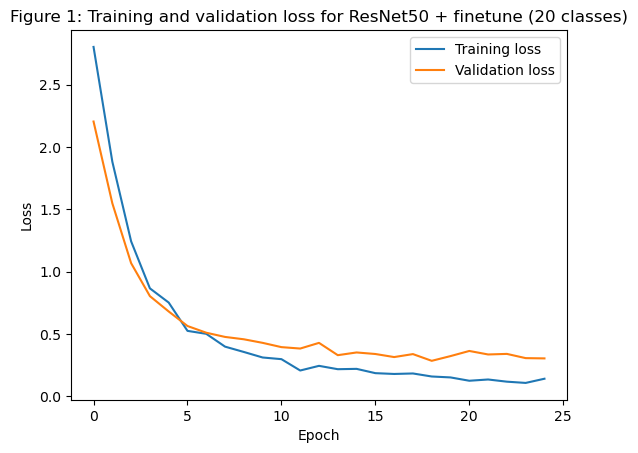

In [ ]:
# Plot the training and validation loss for ResNet 50 with finetuning and data augmentation for 20 classes
plt.Figure(figsize=(10, 5))
plt.plot(train_losses_resnet50_fc_layer4_data_aug_20classes, label='Training loss')
plt.plot(validation_losses_resnet50_fc_layer4_data_aug_20classes, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Figure 1: Training and validation loss for ResNet50 + finetune (20 classes)')
plt.legend()
plt.show()

According to Figure 1, both losses drop steeply from approximately 2.8 and 2.2 for training and validation respectively, the reaason behind is the ResNet50 backbone was pretrained on ImageNet where it already has strong visual features, so the model adapts quickly rather than learning from scratch, therefore adding the 21 pasta classes would allow the model to learn fast. Not to mention that the learning curves are smooth, no oscillations or spikes throughout training, indicating the learning rate (0.001) and batch size (32) were appropriate choices. The choice of using learning scheduler with StepLR, the learning rate halves at epoch 10, from 0.001 to 0.0005, and again at epoch 20 it has reached to 0.00025. As shown, the training loss drops more steeply after each step, showing the scheduler helped squeeze out further improvement. The gap between the training and validation losses indicates mild overfitting, where the model is memorising some training-specific patterns. However, it is not severe since validation loss never increases. Overall, the learning process for ResNet with 21 pasta classes and fine-tune setting from phase 2 such as modifying the learning rate with StepLR, unfreezing layer 4 and final classifier and adding data augmentation is performing greate with slight overfitting in later epochs. 

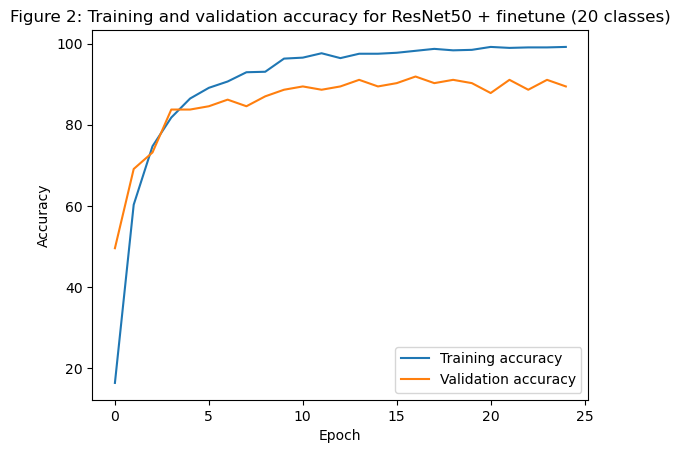

In [ ]:
# Plot the training and validation accuracy for ResNet 50 with finetuning and data augmentation for 20 classes
plt.Figure(figsize=(10, 5))
plt.plot(train_accuracies_resnet50_fc_layer4_data_aug_20classes, label='Training accuracy')
plt.plot(validation_accuracies_resnet50_fc_layer4_data_aug_20classes, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Figure 2: Training and validation accuracy for ResNet50 + finetune (20 classes)')
plt.legend()
plt.show()

According to Figure 2, both accuracies rise steeply in the first 5 epochs, reflecting the strong ImageNet pretrained backbone where the training accuracy reaches to approximately 99% while validation plateaus around around 90%, confirming mild overfitting in later epochs. Validation accuracy oscillates slightly after epoch 10 rather than steadily improving, suggesting the model has largely converged. In addition, the approximate 10% gap between training and validation accuracies is consistent with the loss plot where the model generalises well but memorises some training patterns. Overall, the performance of the model is great with the curve reflects a successful fine-tuning run, achieving 90.69% test accuracy. 

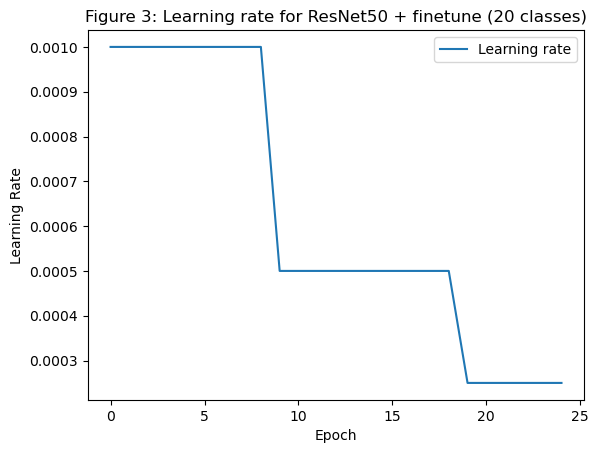

In [ ]:
# Plot the learning rate for ResNet 50 with finetuning and data augmentation for 20 classes
plt.Figure(figsize=(10, 5))
plt.plot(learning_rates_resnet50_fc_layer4_data_aug_20classes, label='Learning rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Figure 3: Learning rate for ResNet50 + finetune (20 classes)')
plt.legend()
plt.show()

According to Figure 3, the learning rate decreases gradually along the epoch during the training. The adjustment of the learning rate allows the model to take smaller update steps as training progresses, preventing it from overshooting the optimal weights. The StepLR scheduler halves the learning rate every 10 epochs, from 0.001 to 0.0005 and to 0.00025, enabling coarse adjustments early on for rapid convergence and finer refinements in later epochs for better generalisation.

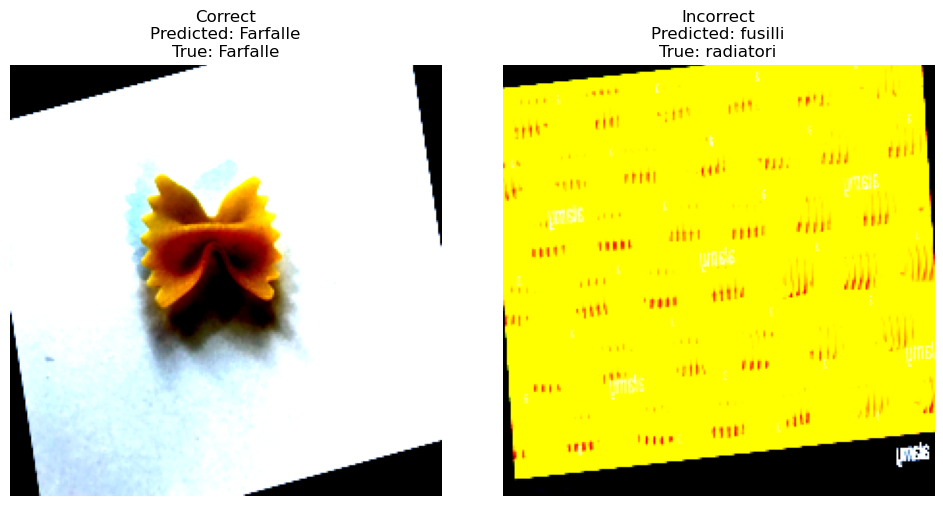

In [ ]:
# Set the class names for the test dataset
class_names = test_dataset_aug.classes

# Set the indices for the correct and incorrect prediction
correct_index = 30
incorrect_index = 380

# Plot the images side by side, correct one first and the incorrect one at the right side
figure, axes = plt.subplots(1, 2, figsize=(10, 5))

# Get the correct prediction first
image, true_label = test_dataset_aug[correct_index]

# Perform inference on the image to get the predicted label 
with torch.no_grad():
    output = model_resnet50_steplr_fc_layer4_data_aug_20classes(image.unsqueeze(0).to(device))
    predicted_label = torch.max(output, 1)[1].item()

# Plot the correct prediction 
axes[0].imshow(image.permute(1, 2, 0).clamp(0, 1))
axes[0].set_title(f"Correct\nPredicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
axes[0].axis('off')

# Get the incorrect prediction with respect to the incorrect index
image, true_label = test_dataset_aug[incorrect_index]

# Perform inference on the image to get the predicted label for incorrect one
with torch.no_grad():
    output = model_resnet50_steplr_fc_layer4_data_aug_20classes(image.unsqueeze(0).to(device))
    predicted_label = torch.max(output, 1)[1].item()

# Display the incorrect prediction at the right side of the plot with the predicted and true labels
axes[1].imshow(image.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title(f"Incorrect\nPredicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
axes[1].axis('off')

# Show the images 
plt.tight_layout()
plt.show()


According to the image above, the model is able to classify the farfalle type with white background, therefore, the model can correctly identifies the distinctive bow-tie shape of Farfalle with high confidence. However, the model predicted fusilli for a radiatori image. The reason behind may be the image is heavily distorted, the extreme yellow colouration, red noise patterns, and overlaid text artifacts suggest a corrupted or incorrectly processed image. It is also understandable where both Fusilli and Radiatori share ridged, complex textures, visually similar, where misclassification likely reflects from the data augmentation where the contrasting did not make the sprial structure more outstanding but rather confusing, so the issue is rather than a model weakness, since no model could reliably classify from such a corrupted input. 

In [ ]:
# Iterate through the test data and perform inference to get the predicted labels 
# Add the true labels and predicted labels to the respective lists for evaluation
model_resnet50_steplr_fc_layer4_data_aug_20classes.eval()

y_true_label, y_predicted_label = [], []

with torch.no_grad():
    for images, labels in test_loader_aug:
        images = images.to(device)
        outputs = model_resnet50_steplr_fc_layer4_data_aug_20classes(images)
        predictions = outputs.argmax(dim=1)

        y_true_label.extend(labels.cpu().numpy())
        y_predicted_label.extend(predictions.cpu().numpy())
    
# Print the result accordingly 
print(f"Accuracy: {accuracy_score(y_true_label, y_predicted_label)*100:.2f}%")
print(classification_report(y_true_label, y_predicted_label , target_names=class_names))

Accuracy: 90.69%
              precision    recall  f1-score   support

  Campanelle       0.94      0.89      0.91        18
    Farfalle       1.00      1.00      1.00        44
     Lumache       0.81      0.72      0.76        18
     Rotelle       1.00      1.00      1.00        17
   Stellette       1.00      0.88      0.94        17
  cannelloni       0.88      0.83      0.86        18
   casarecce       0.95      0.95      0.95        20
   cavatappi       0.85      0.83      0.84        35
  conchiglie       0.87      0.81      0.84        16
    couscous       0.94      0.94      0.94        18
  fettuccine       1.00      1.00      1.00        23
     fusilli       0.82      0.98      0.89        41
     lasagna       0.93      1.00      0.96        25
    macaroni       0.92      0.75      0.83        16
 orecchiette       0.94      0.94      0.94        18
        orzo       0.75      0.94      0.83        16
       penne       0.68      0.81      0.74        16
   radiato

According to the classification report, the overall accuracy is 90.69% which demonstrates effective fine-tuning on 21 classes. According to the precision, recall and f1-score, Farfalle, Rotelle, Fettuccine, Spaghetti achieve perfect scores which means that these classes visually distinctive shapes and the mdoel has no trouble identifyig them. On the other hand, with little inter-class similarity Penne and Lumache are weakest in identification where the f1-score is 0.74 and 0.76 respectively. Since Penne and Lumache both are tube/shell-shaped which can be easily confused with similar classes like rigatoni and conchiglie. Fusilli has high recall of 0.98 but lower precision score of 0.82, this means that the model over-predicts it, likely misclassifying similar spiral/ridged pastas (e.g. radiatori) as fusilli which also explained where Radiatori has the lowest recall of 0.71, frequently missed, consistent with the corrupted incorrect prediction image shown earlier. 

## **Section 2.2 Finetune model with robot images without data augmentation**

The model fine-tuned on 21 pasta classes is loaded as a starting point for a second fine-tuning stage using images captured by the robot. The 3 target classes are fettuccine, fusilli, and penne. The robot-captured images are used to adapt the model to the robot's camera perspective, enabling it to accurately classify these 3 classes before being deployed onto the robot for real-world inference and action.

In [ ]:
# Split the dataset into training, validation and testing sets with a ratio of 60:10:30 for the robot collected images 
splitfolders.ratio("/home/icepomelo/1/dataset_finetune", output="/home/icepomelo/1/dataset_finetune_split", seed=1337, ratio=(0.6, 0.1, 0.3))

Copying files: 132 files [00:00, 8625.82 files/s]


In [ ]:
# Setup and load training dataset 
train_dataset_robot = ImageFolder('/home/icepomelo/1/dataset_finetune_split/train', transform = transform)
train_loader_robot = DataLoader(train_dataset_robot, batch_size = 32, shuffle = True)

# Setup and load validation dataset
validation_dataset_robot = ImageFolder('/home/icepomelo/1/dataset_finetune_split/val', transform = transform)
validation_loader_robot = DataLoader(validation_dataset_robot, batch_size = 32, shuffle = False)

# Setup and load test dataset
test_dataset_robot = ImageFolder('/home/icepomelo/1/dataset_finetune_split/test', transform = transform)
test_loader_robot = DataLoader(test_dataset_robot, batch_size = 32, shuffle = False)

# Setup and load training dataset with data augmentation for robot collected images
train_dataset_robot_aug = ImageFolder('/home/icepomelo/1/dataset_finetune_split/train', transform = test_transform)
train_loader_robot_aug = DataLoader(train_dataset_robot_aug, batch_size = 32, shuffle = True)

# Setup and load validation dataset with data augmentation for robot collected images
validation_dataset_robot_aug = ImageFolder('/home/icepomelo/1/dataset_finetune_split/val', transform = test_transform)
validation_loader_robot_aug = DataLoader(validation_dataset_robot_aug, batch_size = 32, shuffle = False)

# Setup and load test dataset with data augmentation for robot collected images
test_dataset_robot_aug = ImageFolder('/home/icepomelo/1/dataset_finetune_split/test', transform = test_transform)
test_loader_robot_aug = DataLoader(test_dataset_robot_aug, batch_size = 32, shuffle = False)


In [ ]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the pre-trained ResNet50 model
# modify the final fully connected layer to match the number of classes
# The number of classes is 21 as there are 21 pasta classes in the dataset, this is done to match the input of the trained model in the previous step 
model_resnet50_robot_finetune = models.resnet50(pretrained=True)
model_resnet50_robot_finetune.fc = torch.nn.Linear(model_resnet50_robot_finetune.fc.in_features, 21)

# Load the trained model's state dictionary from the file
model_resnet50_robot_finetune.load_state_dict(torch.load('resnet50_steplr_fc_layer4_data_aug_20classes.pth', map_location=device))
model_resnet50_robot_finetune = model_resnet50_robot_finetune.to(device)
model_resnet50_robot_finetune.eval()


/home/icepomelo/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/icepomelo/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### **Section 2.2.1 Test on the robot collect images before fine-tuning**

The 21-class fine-tuned model is evaluated on the robot-collected images to establish a baseline accuracy. This serves as a reference metric to quantify the performance improvement gained from the subsequent fine-tuning on robot-captured data.

In [ ]:
# Initialise the correct and total count for accuracy calculation
correct = 0
total = 0

# Set the model into evaluation mode 
model_resnet50_robot_finetune.eval()

# Start the evaluation on the test dataset of the robot collected images and calculate the accuracy
with torch.no_grad():
    for images, labels in test_loader_robot:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_resnet50_robot_finetune(images)
        predicted = outputs.argmax(dim=1)
        correct = correct + ((predicted == labels).sum().item())
        total = total + labels.size(0)

# Print the test accuracy for the robot collected images before fine-tuning
print(f"Test Accuracy: {correct/total:.2%}")

Test Accuracy: 2.38%


As shown above, the baseline accuracy of 2.38% indicates that the 21-class model fails to generalise to the robot-captured images, highlighting a significant domain gap between the original training data and the robot's camera perspective. This demonstrates the necessity of further fine-tuning on robot-collected data.

### **Section 2.2.2 Fine-tune the ResNet50 with 21 classes with robot captured images**

Further fine-tuning is performed using a similar configuration to the 21-class training, the setting includes unfreezing layer4 and the final classifier while keeping earlier layers frozen, and applying StepLR as the learning rate scheduler. A comparison on whether to use data augmentation is also conducted to compare which setting benefit the classification with model. 

In [ ]:
# Modify the final fully connected layer to match the number of classes in the robot collected dataset
# Since there are only 3 classes in the robot collected dataset, the final fully connected layer is modified to have an output of 3 classes
# The information learned from the previous training on the 21 classes will not be forgetten since 
# the previous layers are not modified and the weights are not updated, hence important information of those 21 classes will still be retained 
num_robot_classes = 3 
model_resnet50_robot_finetune.fc = torch.nn.Linear(model_resnet50_robot_finetune.fc.in_features, num_robot_classes)

# Define loss function and optimiser and learning rate scheduler 
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnet50_robot_finetune.parameters(), lr=0.0001, momentum=0.9)
scheduler_steplr = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_resnet50_robot_finetune = model_resnet50_robot_finetune.to(device)

Using device: cuda


In [ ]:
# Unfreeze layer4 and final classifier (better accuracy, needs more data)
for name, param in model_resnet50_robot_finetune.named_parameters():
    param.requires_grad = name.startswith('layer4') or name.startswith('fc')

In [ ]:
# Start the fine-tune with robot captured image training 
train_losses_robot_images, train_aaccuracies_robot_images, validation_losses_robot_images, validation_accuracies_robot_images, learning_rates_robot_images = train_model(
    model_resnet50_robot_finetune,
    train_loader_robot,
    validation_loader_robot,
    loss_function=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    scheduler=scheduler_steplr,
    num_epochs=25,
    device=device,
)


Epoch [1/25], Training Loss: 1.1594, Training Accuracy: 33.33%
Validation Loss: 1.1064, Validation Accuracy: 41.67%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [2/25], Training Loss: 1.1241, Training Accuracy: 37.18%
Validation Loss: 1.0764, Validation Accuracy: 33.33%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [3/25], Training Loss: 1.0799, Training Accuracy: 38.46%
Validation Loss: 1.0328, Validation Accuracy: 41.67%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [4/25], Training Loss: 1.0583, Training Accuracy: 44.87%
Validation Loss: 1.0044, Validation Accuracy: 50.00%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [5/25], Training Loss: 1.0040, Training Accuracy: 57.69%
Validation Loss: 0.9853, Validation Accuracy: 50.00%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [6/25], Training Loss: 0.9985, Training Accuracy: 58.9

In [ ]:
# Save the fine-tuned model's state dictionary to a file
PATH = "resnet50_finetuned_robot_images.pth"
torch.save(model_resnet50_robot_finetune.state_dict(), PATH)

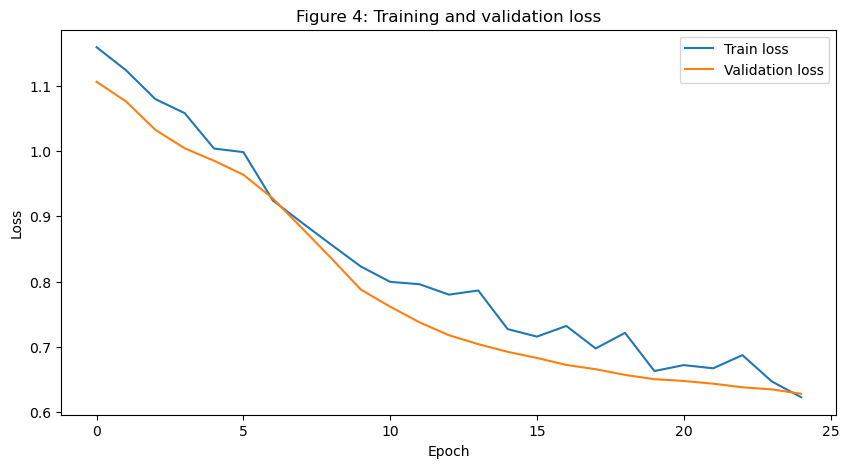

In [ ]:
# Plot the training and validation loss for the fine-tuned model with robot collected images
plt.figure(figsize=(10, 5))
plt.plot(train_losses_robot_images, label='Train loss')
plt.plot(validation_losses_robot_images, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Figure 4: Training and validation loss')
plt.legend()
plt.show()

According to Figure 4, both training and validation losses started relatively high such as around 1.15 for training loss and 1.1 for validation loss. However, the losses decrease steadily across all 25 epochs, indicating the model is learning effectively from the robot-captured images. The training loss oscillates noticeably while validation loss follows a smoother downward curve, likely due to the very small dataset size such that the dataset size only has 132 images. Additionally, it is also notably that the validation loss stays consistently below training loss throughout most of training and along the epoch which is unusual behaviour of the model, thus suggesting the validation set may be slightly easier or that dropout is making training harder. The overall performance is good since the training is stable without overfitting as both losses converge to 0.63 by epoch 25 without divergence.

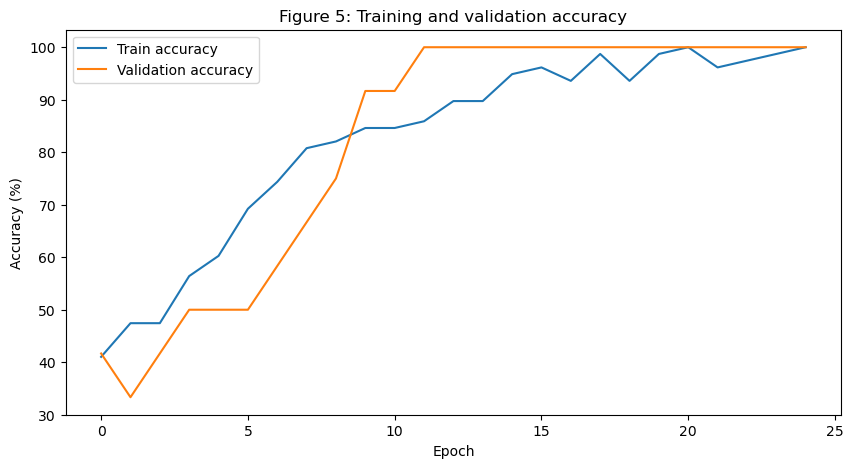

In [ ]:
# Plot the training and validation accuracy for the fine-tuned model with robot collected images
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies_robot_images, label='Train accuracy')
plt.plot(validation_accuracies_robot_images, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Figure 5: Training and validation accuracy')
plt.legend()
plt.show()

According to Figure 5, both accuracies started low with around 41% and slowly improve steadily, reflecting successful adaptation to the robot-captured images. Additionally, validation accuracy rises sharply between epochs 8 to 10, reaching 100% and maintaining it for most of the remaining epochs. As to the training accuracy, it catches up more gradually, reaching approximately 100% by epoch 24, with notable oscillations due to the small dataset size. As for validation accuracy, it consistently exceeds training accuracy after epoch 9, consistent with the loss plot which likely because the 12-image validation set is small enough that all samples happen to be classified correctly.

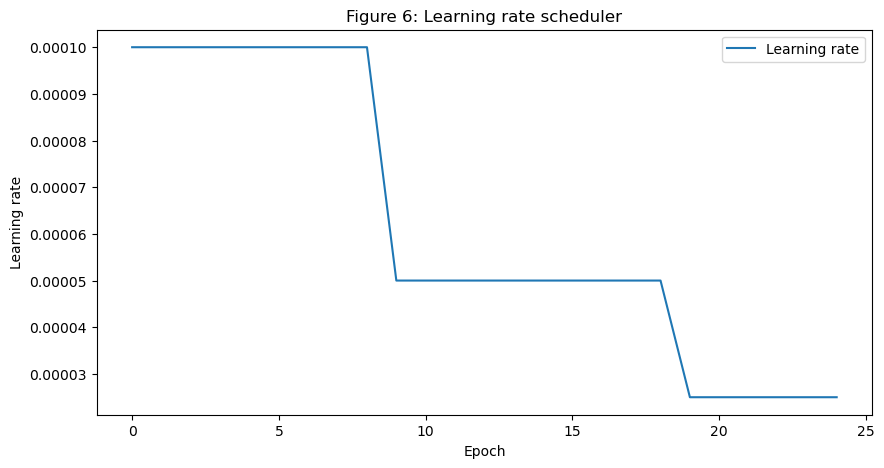

In [ ]:
# Plot the learning rate for the fine-tuned model with robot collected images
plt.figure(figsize=(10, 5))
plt.plot(learning_rates_robot_images, label='Learning rate')
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.title('Figure 6: Learning rate scheduler')
plt.legend()
plt.show()

According to Figure 6, the learning rate decreases gradually along the epoch during the training. The adjustment of the learning rate allows the model to take smaller update steps as training progresses, preventing it from overshooting the optimal weights. The StepLR scheduler halves the learning rate every 8 to 10 epochs, from 0.0001 to 0.00005 and to 0.000025, enabling coarse adjustments early on for rapid convergence and finer refinements in later epochs for better generalisation.

In [ ]:
# Iterate through the test data and perform inference to get the predicted labels 
# Add the true labels and predicted labels to the respective lists for evaluation
model_resnet50_robot_finetune.eval()

class_names = test_dataset_robot.classes

y_true_label, y_predicted_label = [], []

with torch.no_grad():
    for images, labels in test_loader_robot:
        images = images.to(device)
        outputs = model_resnet50_robot_finetune(images)
        predictions = outputs.argmax(dim=1)

        y_true_label.extend(labels.cpu().numpy())
        y_predicted_label.extend(predictions.cpu().numpy())
    
# Print the result accordingly 
print(f"Accuracy: {accuracy_score(y_true_label, y_predicted_label)*100:.2f}%")
print(classification_report(y_true_label, y_predicted_label , target_names=class_names))

Accuracy: 88.10%
              precision    recall  f1-score   support

  fettuccine       1.00      0.77      0.87        13
     fusilli       0.89      1.00      0.94        16
       penne       0.79      0.85      0.81        13

    accuracy                           0.88        42
   macro avg       0.89      0.87      0.88        42
weighted avg       0.89      0.88      0.88        42



According to the classifcation report, the overall accuracy for test dataset is 88.10% which illustrates that the model has successfully adapt to robot-captured images despite only 132 training images with fusilli achieving the strongest performance, with f1-score as 0.94 with perfect recall, further hinting that the model identifies every fusilli sample correctly, with only slight over-prediction. Fettuccine, on the other hand, has perfect precision score of 1.00 but lower recall of 0.77 which means that all fettuccine predictions are correct, but 3 fettuccine samples were misclassified as another class. Penne is the weakest class out of the other classes with a f1-score as 0.81 and the reason behind likely confused with fettuccine as both are smooth, elongated pasta shapes from certain camera angles. Overall, the macro average F1 of 0.88 indicates reasonably balanced performance across all 3 classes. 

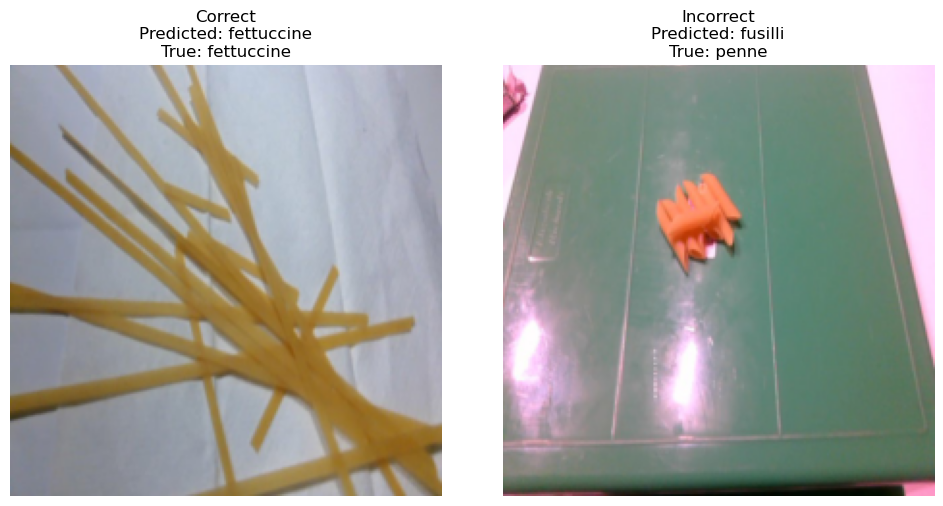

In [ ]:
# Set the indices for the correct and incorrect prediction
correct_index = 10
incorrect_index = 41

# Plot the images side by side, correct one first and the incorrect one at the right side
figure, axes = plt.subplots(1, 2, figsize=(10, 5))

# Get the correct prediction first
image, true_label = test_dataset_robot[correct_index]

# Perform inference on the image to get the predicted label 
with torch.no_grad():
    output = model_resnet50_robot_finetune(image.unsqueeze(0).to(device))
    predicted_label = torch.max(output, 1)[1].item()

# Plot the correct prediction 
axes[0].imshow(image.permute(1, 2, 0).clamp(0, 1))
axes[0].set_title(f"Correct\nPredicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
axes[0].axis('off')

# Get the incorrect prediction with respect to the incorrect index
image, true_label = test_dataset_robot[incorrect_index]

# Perform inference on the image to get the predicted label for incorrect one
with torch.no_grad():
    output = model_resnet50_robot_finetune(image.unsqueeze(0).to(device))
    predicted_label = torch.max(output, 1)[1].item()

# Display the incorrect prediction at the right side of the plot with the predicted and true labels
axes[1].imshow(image.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title(f"Incorrect\nPredicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
axes[1].axis('off')

# Show the images 
plt.tight_layout()
plt.show()


According to the 2 images above, the right side is the incorrect prediction of the 3 pasta type and the one on the left is the correct one. In terms of the correct prediction, the model is able to clearly predict the close-up ijmage showing multiple flat ribbon-like strands, the model correctly identifies the distinctive elongated flat shape of fettuccine. On the other hand, the incorrect precdiction, the penne as fusilli, the reason behind the wrong prediction maybe due to penne sample appears very small relative to the frame, occupying only a small portion of the green surface with strong glare or reflection. The small size and awkward angle makes the ridged tubular shape of penne less distinguishable, causing confusion with fusilli. Not ot mention that the strong background reflection from the green surface likely interferes with the model's ability to extract meaningful shape features. This further highlights that the image quality and object scale significantly impact classification accuracy for robot-captured images which could also be a key limitation. 

## **Section 2.3 Fine-tune model with robot capture image with data augmentation**

Data augmentation is applied to artificially increase the diversity of the limited robot-captured dataset through random flips, rotations, and colour jitter. This aims to improve the model's generalisation by exposing it to varied lighting conditions and orientations, better reflecting the variability encountered during robot deployment which will be conducted within the practical session. 

In [ ]:
# Set up for fine-tuning with data augmentation for the robot collected images
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_resnet50_robot_finetune_aug = models.resnet50(pretrained=True)
model_resnet50_robot_finetune_aug.fc = torch.nn.Linear(model_resnet50_robot_finetune_aug.fc.in_features, 21)
model_resnet50_robot_finetune_aug.load_state_dict(torch.load('resnet50_steplr_fc_layer4_data_aug_20classes.pth', map_location=device))
model_resnet50_robot_finetune_aug = model_resnet50_robot_finetune_aug.to(device)
model_resnet50_robot_finetune_aug.eval()

/home/icepomelo/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/icepomelo/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Set up the fine-tune model with the similar setting as the previous fine-tuning but with data augmentation for the robot collected images
num_robot_classes = 3
model_resnet50_robot_finetune_aug.fc = torch.nn.Linear(model_resnet50_robot_finetune_aug.fc.in_features, num_robot_classes)

# Define loss function and optimiser and learning rate scheduler 
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_resnet50_robot_finetune_aug.parameters(), lr=0.0001, momentum=0.9)
scheduler_steplr = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model_resnet50_robot_finetune_aug = model_resnet50_robot_finetune_aug.to(device)

Using device: cuda


In [ ]:
# Unfreeze layer4 and final classifier
for name, param in model_resnet50_robot_finetune_aug.named_parameters():
    param.requires_grad = name.startswith('layer4') or name.startswith('fc')

In [ ]:
# Start the fine-tune with robot captured image training with data augmentation
train_losses_robot_images_aug, train_aaccuracies_robot_images_aug, validation_losses_robot_images_aug, validation_accuracies_robot_images_aug, learning_rates_robot_images_aug = train_model_robot(
    model_resnet50_robot_finetune_aug,
    train_loader_robot_aug,
    validation_loader_robot_aug,
    loss_function=nn.CrossEntropyLoss(),
    optimizer=optimizer,
    scheduler=scheduler_steplr,
    num_epochs=25,
    device=device,
)

Epoch [1/25], Training Loss: 1.1756, Training Accuracy: 30.77%
Validation Loss: 1.2033, Validation Accuracy: 33.33%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [2/25], Training Loss: 1.1284, Training Accuracy: 32.05%
Validation Loss: 1.1221, Validation Accuracy: 41.67%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [3/25], Training Loss: 1.0795, Training Accuracy: 32.05%
Validation Loss: 1.0590, Validation Accuracy: 50.00%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [4/25], Training Loss: 1.0464, Training Accuracy: 35.90%
Validation Loss: 0.9798, Validation Accuracy: 75.00%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [5/25], Training Loss: 0.9968, Training Accuracy: 55.13%
Validation Loss: 0.9426, Validation Accuracy: 75.00%
Current LR: 0.0001
Validation loss improved — saving best model weights
Epoch [6/25], Training Loss: 0.9570, Training Accuracy: 73.0

In [ ]:
# Save the fine-tuned model's state dictionary to a file
PATH = "resnet50_finetuned_robot_images_aug.pth"
torch.save(model_resnet50_robot_finetune_aug.state_dict(), PATH)

Text(0.5, 1.0, 'Figure 7: Training and validation loss with data augmentation')

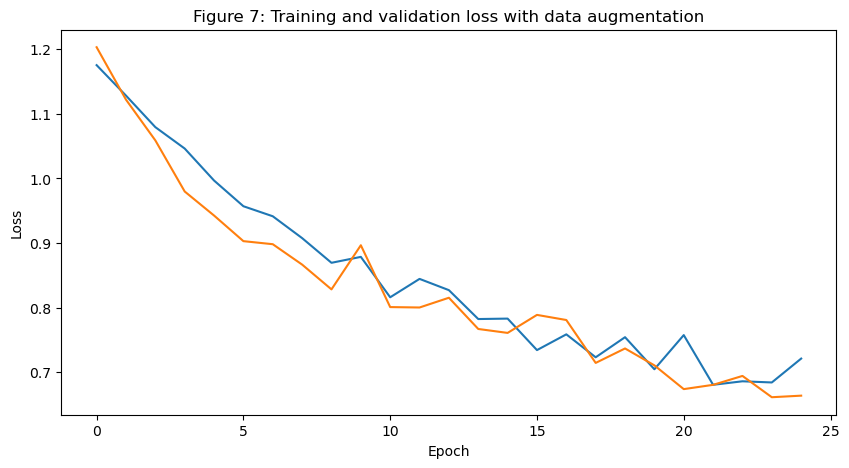

In [ ]:
# Plot the training and validation loss for the fine-tuned model with robot collected images and data augmentation
plt.figure(figsize=(10, 5))
plt.plot(train_losses_robot_images_aug, label='Train loss')
plt.plot(validation_losses_robot_images_aug, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Figure 7: Training and validation loss with data augmentation')

According to Figrue 7, both losses (training and validation) start around 1.18 to 1.20 and decrease steadily across 25 epochs, further showing the model is learning from the augmented robot images. Both the training and validation losses oscillate significantly throughout the epochs compared to the non-augmented run which further shows that a direct consequence of data augmentation help introduce random variation in each batch. Unlike the non-augmented data where training and validation losses remain closely tracked throughout further indicating that model with data augmentation reduced overfitting by regularising the model. Howewver, not to mention that the validation loss slightly undercuts training loss in later epochs, consistent with the earlier non-augmented run. Additioanlly, both losses converge around 0.65 to 0.72 by epoch 25, slightly higher than the model without data augmentation which is around 0.63, suggesting augmentation made the task harder without improving final performance. 

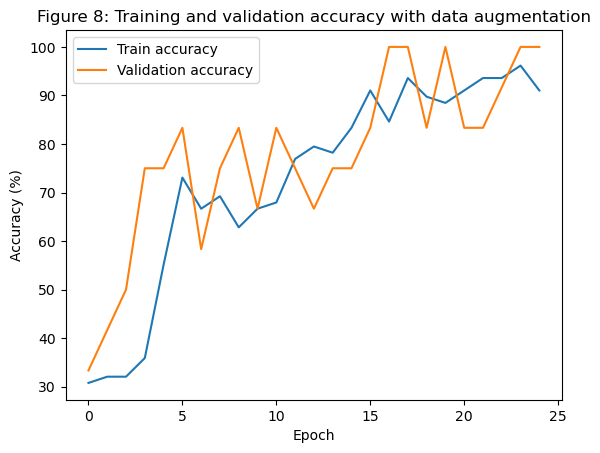

In [ ]:
# Plot the training and validation accuracy for the fine-tuned model with robot collected images and data augmentation
plt.Figure(figsize=(10, 5))
plt.plot(train_aaccuracies_robot_images_aug, label='Train accuracy')
plt.plot(validation_accuracies_robot_images_aug, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Figure 8: Training and validation accuracy with data augmentation')
plt.legend()
plt.show()

According to Figure 8, both accuracies start low around 30% to 35% and gradually increases up to 100% for noth training and validation accuracies, further confirming that the model is learning despite heavy oscillation. In more detail, the validation accuracy fluctuates dramatically throughout training which is swinging between arpimd 65% to 100%, a direct result of the very small image size of 12 images for validation set combined with data augmentation where a single misclassification causes large percentage swings. Not to mention that the training accuracy is notably more stable than validation, gradually climbing to around 92% by epoch 25. In compare with the model without data augmentation, the training accuracy never reaches 100%, indicating augmentation successfully prevents overfitting by making training harder. 

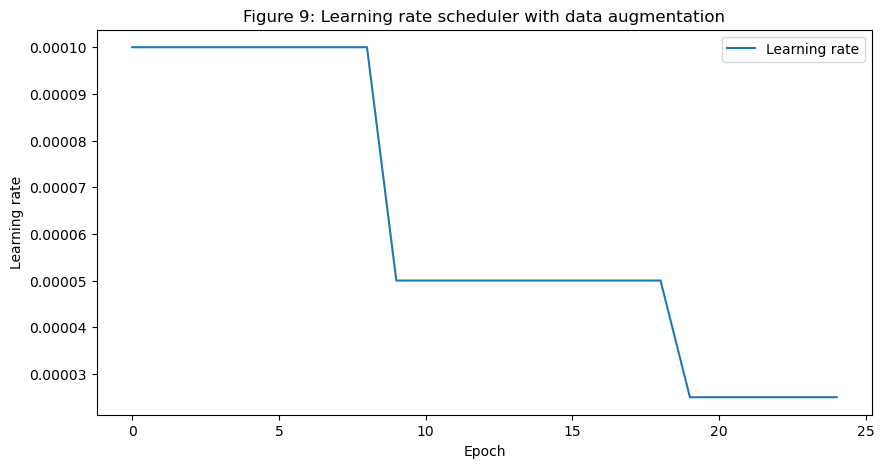

In [ ]:
# Plot the learning rate for the fine-tuned model with robot collected images and data augmentation
plt.figure(figsize=(10, 5))
plt.plot(learning_rates_robot_images_aug, label='Learning rate')
plt.xlabel('Epoch')
plt.ylabel('Learning rate')
plt.title('Figure 9: Learning rate scheduler with data augmentation')
plt.legend()
plt.show()

According to Figure 9, the learning rate decreases gradually along the epoch during the training. The adjustment of the learning rate allows the model to take smaller update steps as training progresses, preventing it from overshooting the optimal weights. The StepLR scheduler halves the learning rate every 8 to 9 epochs, from 0.0001 to 0.00005 and to 0.000025, enabling coarse adjustments early on for rapid convergence and finer refinements in later epochs for better generalisation.

In [ ]:
# Iterate through the test data and perform inference to get the predicted labels 
# Add the true labels and predicted labels to the respective lists for evaluation
model_resnet50_robot_finetune_aug.eval()

class_names = test_dataset_robot_aug.classes

y_true_label, y_predicted_label = [], []

with torch.no_grad():
    for images, labels in test_loader_robot_aug:
        images = images.to(device)
        outputs = model_resnet50_robot_finetune_aug(images)
        predictions = outputs.argmax(dim=1)

        y_true_label.extend(labels.cpu().numpy())
        y_predicted_label.extend(predictions.cpu().numpy())
    
# Print the result accordingly 
print(f"Accuracy: {accuracy_score(y_true_label, y_predicted_label)*100:.2f}%")
print(classification_report(y_true_label, y_predicted_label , target_names=class_names))

Accuracy: 95.24%
              precision    recall  f1-score   support

  fettuccine       0.92      0.92      0.92        13
     fusilli       1.00      1.00      1.00        16
       penne       0.92      0.92      0.92        13

    accuracy                           0.95        42
   macro avg       0.95      0.95      0.95        42
weighted avg       0.95      0.95      0.95        42



According to the classification report, the fine-tuning with data augmentation has an accuracy of 95.24% on the testing dataset which not to mention it also has outperformed the model without data augmentation which has 88.1% as accuracy. The contrary result on the testing data shows that the model with data augmentation helps the model to generalise the pasta classification even with robot images. In more detail, fusilli achieves perfect scores across precision, recall and f1-score of 1.00 in the augmented model, improving from 0.94 f1-score without data augmentation. Fettuccine and penne both improved from 0.87 and 0.81 to 0.92 for f1-score, further indicating that with data augmentation, it helped the model generalise better to varied robot camera conditions. The improvement suggests that with data augmentation such as random flips, rotations and colour jitter effectively simulated the real-world variability of robot-captured images, overall, the mdoel with data augmentation demonstrates more balanced performance across all 3 classes, making it the stronger candidate for robot deployment. 

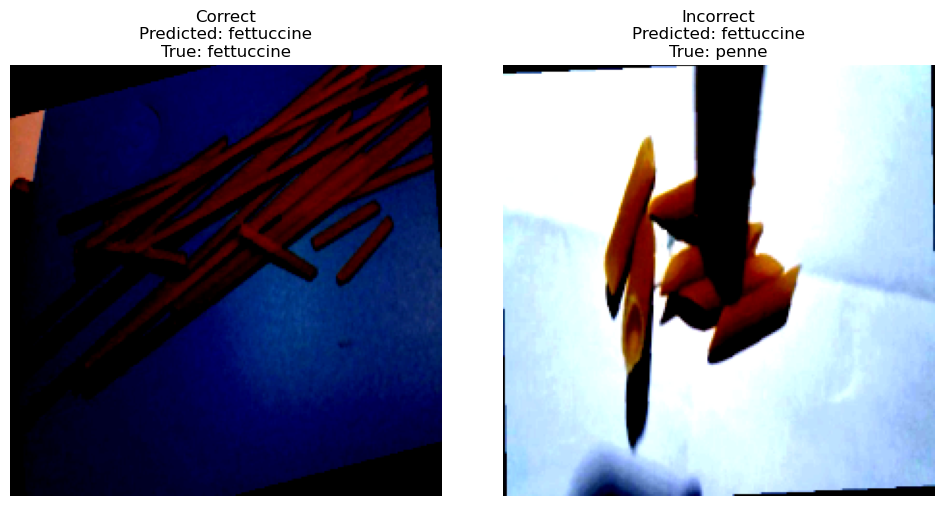

In [114]:
# Set the indices for the correct and incorrect prediction
correct_index = 12
incorrect_index = 34

# Plot the images side by side, correct one first and the incorrect one at the right side
figure, axes = plt.subplots(1, 2, figsize=(10, 5))

# Get the correct prediction first 
image, true_label = test_dataset_robot_aug[correct_index]

# Perform inference on the image to get the predicted label 
with torch.no_grad():
    output = model_resnet50_robot_finetune_aug(image.unsqueeze(0).to(device))
    predicted_label = torch.max(output, 1)[1].item()

# Plot the correct prediction 
axes[0].imshow(image.permute(1, 2, 0).clamp(0, 1))
axes[0].set_title(f"Correct\nPredicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
axes[0].axis('off')

# Get the incorrect prediction with respect to the incorrect index
image, true_label = test_dataset_robot_aug[incorrect_index]

# Perform inference on the image to get the predicted label for incorrect one
with torch.no_grad():
    output = model_resnet50_robot_finetune_aug(image.unsqueeze(0).to(device))
    predicted_label = torch.max(output, 1)[1].item()

# Display the incorrect prediction at the right side of the plot with the predicted and true labels
axes[1].imshow(image.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title(f"Incorrect\nPredicted: {class_names[predicted_label]}\nTrue: {class_names[true_label]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

According to the image above, the model has correctly determine fettuccine despite heavy blue tinting and dark lighting, further suggesting that the mdoel with data augmentation including the colour jitter helped the model become robust to colour distortion. However, the model also got the penne image wrong, misclassified as fettuccine. The reason may be that the image is captured from a top-down angle with a robotic arm partially obstructing the view, significantly altering the pasta's apparent shape. Not to mention that the tubular hollow structure of penne is not visible from this angle, such that the pieces appear as flat elongated shapes, closely resembling fettuccine strands. Further highlighting a limitation where the camera angle and occlusion from the robot arm directly may influence in the misclassification, an issue that more training data from varied angles could address. 

## **Section 3: Deploy and test on robot**

The fine-tuned image classification model was deployed onto a robot operating within the ROS2 (Robot Operating System 2) framework. The deployment process enabled the robot to use its onboard camera for real-time pasta classification and respond with predefined robotic movements based on the detected pasta type.


## **Section 3.1 Connecting to the Robot**

The robot was accessed remotely using the NoMachine remote desktop application. To establish communication, both the development computer and the robot were connected to the same Wi-Fi network. Once connected, the ROS2 environment running on the robot could be remotely controlled.

## **Section 3.2 Workspace and Package Configuration**

A ROS2 workspace was created to manage the deployment files and custom classification node. The workspace followed the standard ROS2 directory structure.

The workspace was created in the following format:

```bash
YourMQ_ID/comp8430/src
```

Inside the `src` directory, a ROS2 Python package named `classification_topic` was created using:

```bash
ros2 pkg create classification_topic --build-type ament_python --dependencies rclpy
```

This command automatically generated the required ROS2 package structure, including configuration files and Python package directories.

The resulting structure was:

```bash
YourMQ_ID
└── comp8430
    └── src
        └── classification_topic
            ├── package.xml
            ├── resource
            │   └── classification_topic
            ├── setup.cfg
            ├── setup.py
            ├── test
            └── classification_topic
                └── __init__.py
```



## **Section 3.3 Uploading the trained model**

The trained image classification checkpoint and class label mapping file were uploaded to the robot and placed inside the ROS2 package directory.

The deployment used a pretrained ResNet50 model checkpoint stored in PyTorch `.pth` format.

The updated workspace structure became:

```bash
YourMQ_ID
└── comp8430
    └── src
        └── classification_topic
            ├── package.xml
            ├── resource
            ├── setup.cfg
            ├── setup.py
            ├── test
            └── classification_topic
                ├── __init__.py
                ├── resnet50-0676ba61.pth
                └── imagenet_classes.txt
```

The `imagenet_classes.txt` file was used to map prediction indices generated by the classifier to human-readable pasta class labels.



## **Section 3.4 Classification Subscriber Node**

A ROS2 subscriber node named `classification_sub.py` was implemented inside the `classification_topic` package. The subscriber node was responsible for:

- receiving image data from the robot camera topic,
- preprocessing captured frames,
- performing inference using the fine-tuned CNN classifier,
- generating pasta class predictions,
- and triggering robotic actions based on the detected pasta type.

The subscriber node was registered as an executable in the `setup.py` configuration file:

```python
entry_points={
    'console_scripts': [
        "classification_subscriber = classification_topic.classification_sub:main",
    ],
},
```

This configuration allowed the node to be launched directly using the ROS2 command-line interface.



## **Section 3.5 Building the ROS2 Workspace**

Before running the classification node, the ROS2 workspace was compiled using the `colcon build` system.

The following command was executed from the workspace root directory:

```bash
cd ~/YourMQ_ID/comp8430
colcon build
```

This process generated the standard ROS2 build, install, and log directories:

```bash
YourMQ_ID
└── comp8430
    ├── build
    ├── install
    ├── log
    └── src
```

After compilation, the workspace environment was sourced to make the package visible to ROS2:

```bash
source install/setup.zsh
```

This step was necessary before executing any custom ROS2 nodes.


## **Section 3.6 Running the Camera and Classification System**

The robot camera node was first launched using:

```bash
ros2 launch peripherals depth_camera.launch.py
```

This command initialized the onboard depth camera and began publishing image data to ROS2 topics.

A second terminal was then used to launch the classification subscriber node:

```bash
ros2 run classification_topic classification_subscriber
```

The subscriber continuously received camera frames, processed the images, and generated predictions in real time.



## **Section 3.7 Real-Time Image Classification Workflow**

The deployed system operated using the following pipeline:

```text
Robot Camera
      ↓
ROS2 Camera Topic
      ↓
Classification Subscriber Node
      ↓
Image Preprocessing
      ↓
ResNet50 Inference
      ↓
Predicted Pasta Class
      ↓
Robot Action Execution
```

Captured images were resized and normalized before being passed into the CNN classifier. The model output class probabilities, and the class with the highest confidence score was selected as the final prediction.



## **Section 3.8 Robot actions determination**

The robot executed predefined actions depending on the detected pasta class. The selected actions were designed to produce clear and visually distinguishable robot behaviours during the demonstration.

| Predicted Pasta Class | Robot Action |
|---|---|
| Fettuccine | Move Forward |
| Fusilli | Turn Right |
| Penne | Reverse |
| Other Classes | Stop and Log Warning |

If a pasta class outside the selected deployment classes was detected, the robot stopped movement and generated a warning message in the ROS2 console. This safety mechanism prevented unintended behaviour caused by uncertain or unsupported classifications.

The control logic implemented in the subscriber node followed the structure below:

```python
if prediction == "fettuccine":
    move_forward()

elif prediction == "fusilli":
    turn_right()

elif prediction == "penne":
    reverse()

else:
    stop_robot()
    log_warning()
```


## **Section 3.9 Deployment Challenges**

Several challenges were encountered during deployment and testing, including:

- lighting variations affecting image quality,
- unstable predictions caused by rapid movement,
- inference latency during real-time processing,
- and differences between robot camera images and the original training dataset.

In some cases, partial visibility or motion blur temporarily reduced classification confidence. Despite these challenges, the deployed system maintained stable real-time performance under normal operating conditions.



## **Section 3.10 Demonstration Video**

A demonstration video was recorded to showcase the deployed system. The video illustrated the robot identifying different pasta types using its onboard camera and performing the corresponding actions in real time.

The demonstration confirmed the successful integration of computer vision, ROS2 communication, and robotic motion control within a real-world deployment environment.




# **Conclusion**

To sum up, phase 3 successfully extended the pasta classification work from Phase 2 into a real-world robot deployment scenario, covering three key stages: robot image capture, model fine-tuning, and live deployment using ROS2.

The fine-tuned ResNet50 model includes conducting training on 21 pasta classes using the best settings identified in Phase 2 and later further adapted for robot-captured images of three selected pasta classes: fettuccine, fusilli, and penne. Fine-tuning without data augmentation achieved a test accuracy of 88.1%, while introducing data augmentation which including random flips, rotations, and colour jitter, the model's performance improved this to 95.24%. The augmented model demonstrated more balanced performance across all three classes, with fusilli achieving a perfect f1-score of 1.00 and both fettuccine and penne improving from 0.87 and 0.81 to 0.92, confirming that data augmentation effectively helped the model generalise to the varied lighting and angle conditions produced by the robot camera.

The fine-tuned model was successfully deployed onto the robot within a ROS2 framework, enabling real-time pasta classification through the onboard depth camera. The robot was programmed to perform distinct actions for each predicted class — moving forward for fettuccine, turning right for fusilli, and reversing for penne — demonstrating a complete pipeline from image capture to actionable robot behaviour.

Several limitations were identified during testing. Domain shift between studio-collected training images and robot-captured images remained a challenge, as differences in lighting, camera angle, object scale, and occasional occlusion from the robotic arm contributed to misclassifications. In particular, top-down angles obscured the distinctive shapes of some pasta types, causing confusion between classes. These findings highlight that image quality and capture conditions significantly impact classification accuracy in real-world deployment.

In conclusion, Phase 3 demonstrated that a pre-trained CNN can be effectively adapted for robot deployment through targeted fine-tuning and data augmentation, achieving high accuracy even with a limited number of robot-captured training images. Future work could address the identified limitations by collecting a larger and more diverse set of robot images from varied angles and lighting conditions, and by incorporating confidence thresholding to reduce the impact of uncertain predictions during deployment.